# Clase jueves 5 de febrero.
## Juan Pedro Ley Valdez
## Feature Engineering, transformaciones

In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [3]:
df_salarios = pd.read_csv("Salarios_minimos.csv")

In [8]:
x_sal_raw = df_salarios['Periodo'].values
y_sal = df_salarios['Salario'].values
x_sal_raw = x_sal_raw.reshape(-1, 1)

model = LinearRegression()
model.fit(x_sal_raw, y_sal)

LinearRegression()

In [9]:
from sklearn.metrics import r2_score

# Predicciones
y_pred = model.predict(x_sal_raw)

# Calcular R²
r2 = r2_score(y_sal, y_pred)

print("R²:", r2)


R²: 0.98445666630952


In [11]:
# Normalizado
x_sal_norm = x_sal_raw/1000
model_norm = LinearRegression()
model_norm.fit(x_sal_norm, y_sal)

y_pred_norm = model_norm.predict(x_sal_norm)

# Calcular R²
r2_norm = r2_score(y_sal, y_pred_norm)

print("R²:", r2)


R²: 0.98445666630952


In [12]:
df_salarios.describe()

,Periodo,Salario
count,34.000000,34.000000
mean,2002.177353,39.560588
std,9.117739,23.233915
min,1988.250000,8.000000
25%,1995.075000,16.830000
50%,2001.500000,41.250000
75%,2009.750000,56.795000
max,2018.000000,88.360000


# EDA

## Boston Housing

In [29]:
df = pd.read_excel("boston_housing.xlsx")

In [31]:
df_boston = pd.read_excel("boston_housing.xlsx")

In [30]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [25]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [28]:
df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


# Escalamiento

## Min-Max

In [34]:


X = df_boston.drop("MEDV", axis=1).values  
y = df_boston["MEDV"].values              

X_min = X.min(axis=0)
X_max = X.max(axis=0)

X_scaled = (X - X_min) / (X_max - X_min)



In [37]:

X_scaled = pd.DataFrame(
    X_scaled,
    columns=df_boston.drop("MEDV", axis=1).columns
)

X_scaled

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.000634,0.18,0.083273,0.0,0.022084,0.031253,0.647998,0.129442,0.000000,0.399247,0.032209,1.000000,0.099449
1,0.002740,0.00,0.254867,0.0,0.012125,0.029656,0.786573,0.167793,0.001504,0.321077,0.038549,1.000000,0.226744
2,0.002738,0.00,0.254867,0.0,0.012125,0.037578,0.606526,0.167793,0.001504,0.321077,0.038549,0.989737,0.070379
3,0.003248,0.00,0.078587,0.0,0.010537,0.035639,0.451767,0.215676,0.003008,0.292125,0.040832,0.994276,0.037026
4,0.006928,0.00,0.078587,0.0,0.010537,0.037184,0.536733,0.215676,0.003008,0.292125,0.040832,1.000000,0.110159
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.006284,0.00,0.430065,0.0,0.027136,0.031440,0.687446,0.058985,0.000000,0.365953,0.046665,0.987619,0.242962
502,0.004542,0.00,0.430065,0.0,0.027136,0.026535,0.764320,0.050629,0.000000,0.365953,0.046665,1.000000,0.224908
503,0.006096,0.00,0.430065,0.0,0.027136,0.035411,0.908965,0.045382,0.000000,0.365953,0.046665,1.000000,0.119645
504,0.010996,0.00,0.430065,0.0,0.027136,0.033524,0.891769,0.055062,0.000000,0.365953,0.046665,0.991301,0.145349


In [46]:
X_scaled.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,0.127346,0.132953,0.331837,0.140765,0.103374,0.125663,0.582702,0.220534,0.115885,0.461954,0.101484,0.838346,0.300116
std,0.240726,0.230487,0.258458,0.312765,0.237730,0.282253,0.334848,0.283180,0.306078,0.261537,0.222128,0.316008,0.185585
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.004961,0.000000,0.124009,0.000000,0.009238,0.024891,0.312179,0.056885,0.004511,0.338448,0.036520,0.919550,0.157512
50%,0.014514,0.000000,0.250901,0.000000,0.022084,0.028635,0.648503,0.122265,0.006015,0.415171,0.041339,0.984265,0.264688
75%,0.082237,0.181000,0.652487,0.000000,0.037818,0.035131,0.898597,0.227476,0.034586,0.554140,0.044636,0.996760,0.406518
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Standard (distribución z)

In [42]:
mu = X.mean(axis=0)
sigma = X.std(axis=0)


X_standard = (X - mu) / sigma
X_standard = pd.DataFrame(
    X_standard,
    columns=df_boston.drop("MEDV", axis=1).columns
)

X_std_df = pd.DataFrame(
    X_standard,
    columns=df_boston.drop("MEDV", axis=1).columns
)

X_std_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.526893,0.204324,-0.962669,-0.450511,-0.342280,-0.334818,0.195195,-0.321993,-0.378985,-0.239999,-0.312176,0.512058,-1.082336
1,-0.518136,-0.577404,-0.298101,-0.450511,-0.384216,-0.340481,0.609451,-0.186430,-0.374068,-0.539182,-0.283604,0.512058,-0.395747
2,-0.518144,-0.577404,-0.298101,-0.450511,-0.384216,-0.312386,0.071220,-0.186430,-0.374068,-0.539182,-0.283604,0.479549,-1.239130
3,-0.516024,-0.577404,-0.980819,-0.450511,-0.390902,-0.319263,-0.391416,-0.017173,-0.369150,-0.649991,-0.273318,0.493927,-1.419029
4,-0.500721,-0.577404,-0.980819,-0.450511,-0.390902,-0.313783,-0.137420,-0.017173,-0.369150,-0.649991,-0.273318,0.512058,-1.024570
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,-0.503399,-0.577404,0.380429,-0.450511,-0.321009,-0.334156,0.313121,-0.571049,-0.378985,-0.367429,-0.247032,0.472840,-0.308273
502,-0.510642,-0.577404,0.380429,-0.450511,-0.321009,-0.351550,0.542928,-0.600586,-0.378985,-0.367429,-0.247032,0.512058,-0.405650
503,-0.504180,-0.577404,0.380429,-0.450511,-0.321009,-0.320072,0.975327,-0.619133,-0.378985,-0.367429,-0.247032,0.512058,-0.973406
504,-0.483807,-0.577404,0.380429,-0.450511,-0.321009,-0.326764,0.923923,-0.584913,-0.378985,-0.367429,-0.247032,0.484502,-0.834768


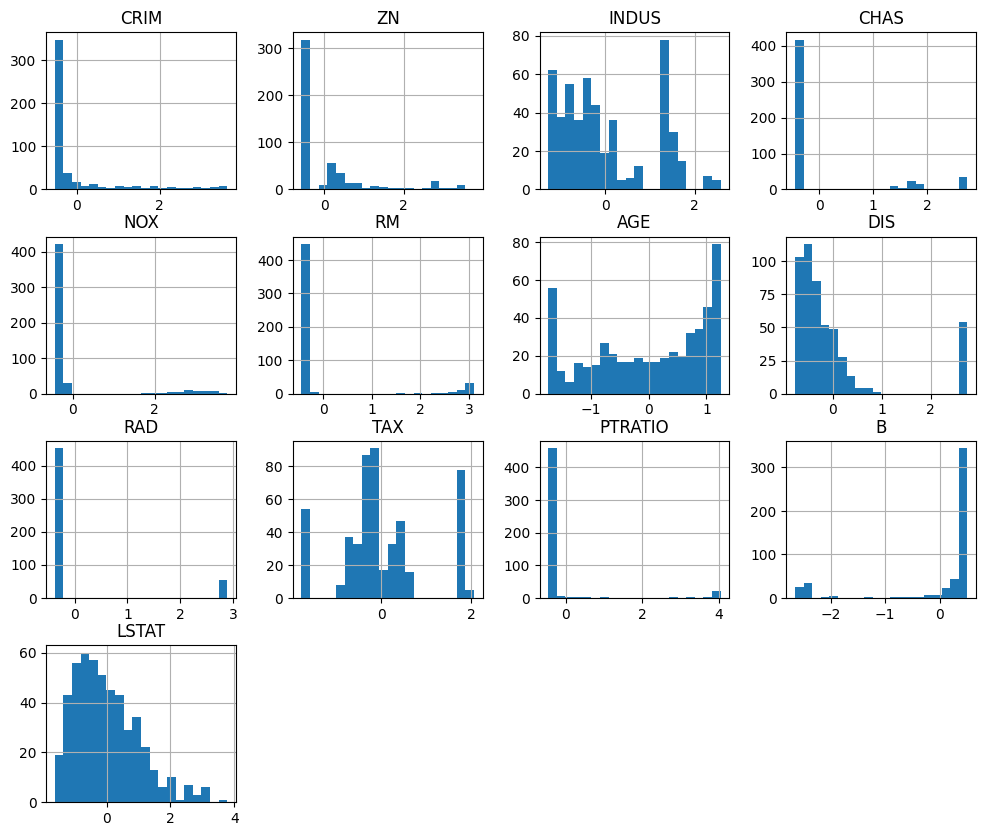

In [45]:

X_std_df.hist(figsize=(12,10), bins=20)

plt.show()
